Link Video : https://drive.google.com/file/d/1of-spmlTRrNei2VeWjNJOor6jKHc9VGb/view?usp=sharing

# Data Loading, Data Scaling, dan Data Splitting

Pada tahap ini dilakukan beberapa proses awal sebelum membangun model Autoencoder, yaitu:

1. Menghubungkan Google Colab dengan Google Drive.
2. Memuat dataset dua kelas (Car dan Plane).
3. Melakukan preprocessing citra berupa resize menjadi 28×28 piksel dan normalisasi nilai piksel ke rentang 0–1.
4. Menampilkan beberapa contoh citra dari dataset.
5. Membagi dataset menjadi:
   - 80% Training Set
   - 10% Validation Set
   - 10% Test Set

Normalisasi diperlukan agar proses training menjadi lebih stabil dan mempercepat konvergensi model Autoencoder.

### Import Library

Library yang digunakan meliputi **NumPy** untuk pengolahan array, **Matplotlib** untuk visualisasi citra, **PIL** untuk membaca file gambar, **TensorFlow** untuk membangun model Autoencoder, serta **Scikit-learn** untuk membagi dataset menjadi training, validation, dan test set.

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model



Pada bagian ini saya mengimpor library yang dibutuhkan untuk membangun model Autoencoder. Library ini digunakan untuk membuat arsitektur model, melatih model, dan menampilkan diagram arsitektur.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Loading Dataset

Dataset terdiri dari dua kelas, yaitu **Car** dan **Plane**. Seluruh citra dari kedua kelas dimuat ke dalam memori, kemudian setiap gambar dikonversi menjadi grayscale berukuran **28 × 28 piksel** agar memiliki dimensi yang seragam. Label diberikan dalam bentuk numerik, yaitu **0** untuk Car dan **1** untuk Plane.

In [ ]:

# PATH CONFIGURATION

from google.colab import drive
import os

drive.mount('/content/drive')

# Root folder
ROOT_DIR = "/content/drive/MyDrive/UAS Deep Learning"

# Dataset utama
DATASET_DIR = os.path.join(ROOT_DIR, "dataset s2")

# Version 2 Dataset

VERSION2_DIR = os.path.join(DATASET_DIR, "version2")

VERSION2_TRAIN_DIR = os.path.join(VERSION2_DIR, "train")
VERSION2_TEST_DIR  = os.path.join(VERSION2_DIR, "test")
VERSION2_DATA_DIR  = os.path.join(VERSION2_DIR, "data")

VERSION2_CAR_TRAIN = os.path.join(VERSION2_TRAIN_DIR, "car")
VERSION2_PLANE_TRAIN = os.path.join(VERSION2_TRAIN_DIR, "plane")

VERSION2_CAR_TEST = os.path.join(VERSION2_TEST_DIR, "car")
VERSION2_PLANE_TEST = os.path.join(VERSION2_TEST_DIR, "plane")

# Overhead Dataset

OVERHEAD_DIR = os.path.join(DATASET_DIR, "overhead")

OVERHEAD_TRAIN_DIR = os.path.join(OVERHEAD_DIR, "training")
OVERHEAD_TEST_DIR  = os.path.join(OVERHEAD_DIR, "testing")

OVERHEAD_CAR_TRAIN = os.path.join(OVERHEAD_TRAIN_DIR, "car")
OVERHEAD_PLANE_TRAIN = os.path.join(OVERHEAD_TRAIN_DIR, "plane")

OVERHEAD_CAR_TEST = os.path.join(OVERHEAD_TEST_DIR, "car")
OVERHEAD_PLANE_TEST = os.path.join(OVERHEAD_TEST_DIR, "plane")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(ROOT_DIR)

print("\nVersion2")
print(VERSION2_CAR_TRAIN)
print(VERSION2_PLANE_TRAIN)
print(VERSION2_CAR_TEST)
print(VERSION2_PLANE_TEST)

print("\nOverhead")
print(OVERHEAD_CAR_TRAIN)
print(OVERHEAD_PLANE_TRAIN)
print(OVERHEAD_CAR_TEST)
print(OVERHEAD_PLANE_TEST)

/content/drive/MyDrive/UAS Deep Learning

Version2
/content/drive/MyDrive/UAS Deep Learning/dataset s2/version2/train/car
/content/drive/MyDrive/UAS Deep Learning/dataset s2/version2/train/plane
/content/drive/MyDrive/UAS Deep Learning/dataset s2/version2/test/car
/content/drive/MyDrive/UAS Deep Learning/dataset s2/version2/test/plane

Overhead
/content/drive/MyDrive/UAS Deep Learning/dataset s2/overhead/training/car
/content/drive/MyDrive/UAS Deep Learning/dataset s2/overhead/training/plane
/content/drive/MyDrive/UAS Deep Learning/dataset s2/overhead/testing/car
/content/drive/MyDrive/UAS Deep Learning/dataset s2/overhead/testing/plane


## Dataset Selection

Pada soal ini, saya akan menggunakan dataset **Overhead-MNIST** dari folder **overhead** dengan dua kelas, yaitu **Car** dan **Plane**, sesuai dengan pembagian dataset berdasarkan gender dan NIM. Saya memilih folder **overhead** karena menyediakan citra dalam format gambar yang telah dikelompokkan berdasarkan kelas, sehingga lebih mudah digunakan untuk proses loading data, preprocessing, visualisasi, dan pembangunan model Autoencoder. Selain itu, pada soal hanya disebutkan penggunaan dataset **Overhead-MNIST** tanpa menginstruksikan penggunaan format **version2**, sehingga penggunaan folder **overhead** dipilih agar tetap sesuai dengan ketentuan yang diberikan.

> **Catatan:** Dataset yang digunakan sudah memiliki folder **training** dan **testing**. Namun, pada soal diminta untuk membagi dataset menjadi **80% training**, **10% validation**, dan **10% testing**. Oleh karena itu, seluruh data terlebih dahulu digabung, kemudian dilakukan pembagian ulang agar sesuai dengan ketentuan pada soal.

In [ ]:
IMG_SIZE = 28

images = []
labels = []

classes = {
    "car":0,
    "plane":1
}

dataset_paths = [
    OVERHEAD_CAR_TRAIN,
    OVERHEAD_PLANE_TRAIN,
    OVERHEAD_CAR_TEST,
    OVERHEAD_PLANE_TEST
]

for folder in dataset_paths:

    class_name = os.path.basename(folder).lower()
    label = classes[class_name]

    for file in os.listdir(folder):

        image_path = os.path.join(folder,file)

        image = Image.open(image_path).convert("L")
        image = image.resize((IMG_SIZE,IMG_SIZE))

        image = np.array(image)

        images.append(image)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Images :",images.shape)
print("Labels :",labels.shape)

Images : (2000, 28, 28)
Labels : (2000,)


### Dataset Inspection

Sebelum melakukan preprocessing, dilakukan inspeksi terhadap salah satu sampel citra untuk memastikan karakteristik dasar dataset. Tahap ini bertujuan untuk memverifikasi format warna (*color mode*) dan ukuran citra sehingga preprocessing yang dilakukan benar-benar diperlukan dan tidak mengubah informasi asli pada dataset.

In [ ]:
from PIL import Image
import os

sample = os.path.join(OVERHEAD_CAR_TRAIN, os.listdir(OVERHEAD_CAR_TRAIN)[0])

img = Image.open(sample)

print(img.mode)
print(img.size)

L
(28, 28)


### Dataset Overview

Setelah proses loading selesai, dilakukan pemeriksaan terhadap informasi dasar dataset, seperti jumlah citra, dimensi data, jumlah kelas, serta distribusi setiap kelas. Informasi ini digunakan untuk memastikan bahwa seluruh data berhasil dimuat dengan benar dan memiliki distribusi yang seimbang sebelum digunakan pada proses pelatihan model.

In [ ]:
# Dataset information
print("=" * 40)
print("DATASET OVERVIEW")
print("=" * 40)

print(f"Total Images  : {len(images)}")
print(f"Image Shape   : {images.shape}")
print(f"Total Labels  : {len(labels)}")
print(f"Image Size    : {images[0].shape}")

print("\nClass Distribution")

unique, counts = np.unique(labels, return_counts=True)

class_names = {
    0: "Car",
    1: "Plane"
}

for label, count in zip(unique, counts):
    print(f"{class_names[label]:<6}: {count} images")

DATASET OVERVIEW
Total Images  : 2000
Image Shape   : (2000, 28, 28)
Total Labels  : 2000
Image Size    : (28, 28)

Class Distribution
Car   : 1000 images
Plane : 1000 images


Berdasarkan hasil pemeriksaan, dataset terdiri dari **2.000 citra grayscale** dengan ukuran **28 × 28 piksel**. Setiap kelas memiliki **1.000 citra**, sehingga distribusi data berada dalam kondisi seimbang (*balanced dataset*). Kondisi ini mengurangi potensi bias terhadap salah satu kelas dan memastikan proses pembagian dataset menghasilkan proporsi kelas yang tetap konsisten.

### Class Distribution

Distribusi jumlah citra pada setiap kelas divisualisasikan untuk memastikan bahwa dataset memiliki jumlah data yang seimbang. Distribusi kelas yang seimbang penting agar model tidak cenderung mempelajari salah satu kelas lebih dominan dibandingkan kelas lainnya.

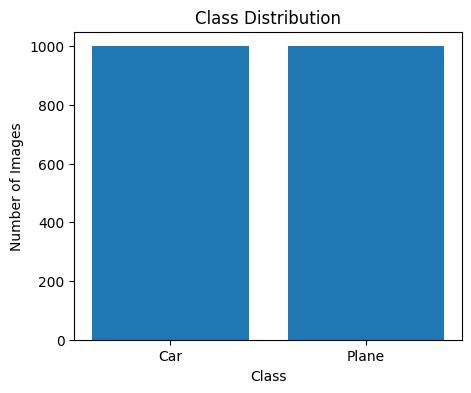

In [ ]:
class_names = ["Car", "Plane"]

plt.figure(figsize=(5,4))

plt.bar(class_names, counts)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

Berdasarkan grafik di atas, saya dapat melihat bahwa dataset memiliki distribusi yang seimbang, yaitu **1.000 citra kelas Car** dan **1.000 citra kelas Plane**. Kondisi ini menunjukkan bahwa tidak terdapat ketimpangan jumlah data antar kelas (*balanced dataset*), sehingga model dapat mempelajari kedua kelas dengan proporsi yang sama dan mengurangi kemungkinan bias terhadap salah satu kelas.

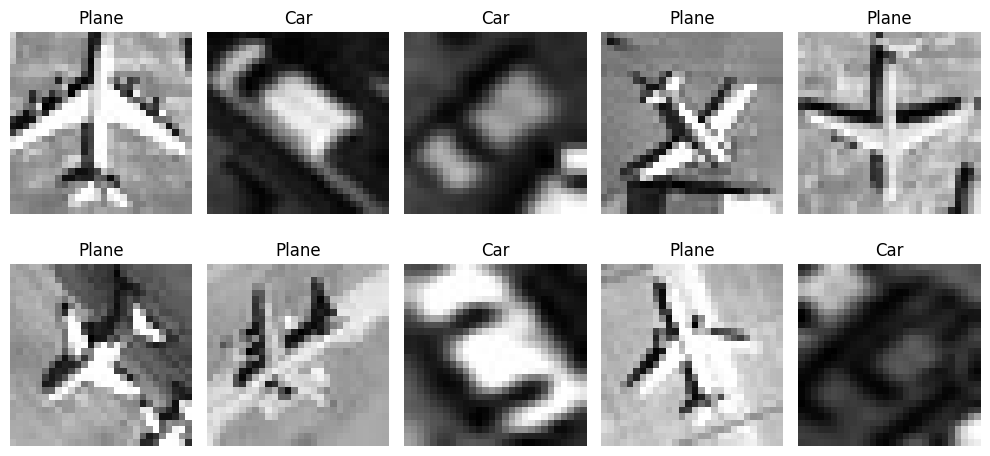

In [ ]:
plt.figure(figsize=(10,5))

random_idx = np.random.choice(len(images), 10, replace=False)

for i, idx in enumerate(random_idx):

    plt.subplot(2,5,i+1)

    plt.imshow(images[idx], cmap="gray")

    plt.title(class_names[labels[idx]])

    plt.axis("off")

plt.tight_layout()

plt.show()

Berdasarkan contoh citra di atas, saya dapat melihat bahwa kedua kelas memiliki karakteristik visual yang berbeda. Citra **Car** umumnya menampilkan objek kendaraan berukuran kecil yang terlihat dari atas, sedangkan citra **Plane** memiliki bentuk pesawat yang lebih mudah dikenali dengan bagian sayap yang terlihat jelas. Selain itu, seluruh citra sudah berbentuk **grayscale** dengan ukuran **28 × 28 piksel**, sehingga tidak diperlukan proses konversi warna maupun resize sebelum dilakukan preprocessing lebih lanjut.

### Pixel Value Inspection

Sebelum melakukan normalisasi, saya memeriksa rentang nilai piksel pada dataset untuk memastikan apakah data masih berada pada skala asli. Pemeriksaan ini diperlukan agar proses normalisasi dilakukan berdasarkan kondisi data yang sebenarnya.

In [ ]:
print(images.min())
print(images.max())

0
255


Hasil pemeriksaan menunjukkan bahwa nilai piksel berada pada rentang **0 hingga 255**, yang merupakan rentang standar untuk citra grayscale 8-bit. Oleh karena itu, pada tahap berikutnya saya akan melakukan normalisasi dengan membagi setiap nilai piksel menggunakan **255**, sehingga seluruh nilai piksel berada pada rentang **0–1** dan lebih sesuai untuk proses pelatihan model Autoencoder.

### Data Type Inspection

Selain memeriksa ukuran dan nilai piksel, saya juga memeriksa tipe data (*data type*) yang digunakan pada dataset. Informasi ini penting karena proses normalisasi akan mengubah tipe data menjadi **float32**, yang lebih sesuai untuk proses komputasi pada model Deep Learning.

In [ ]:
print("Image Data Type :", images.dtype)

Image Data Type : uint8


Hasil pemeriksaan menunjukkan bahwa citra masih menggunakan tipe data **uint8**, yang merupakan format standar penyimpanan citra digital dengan rentang nilai 0–255. Pada tahap normalisasi, tipe data ini akan diubah menjadi **float32** agar proses perhitungan selama pelatihan model menjadi lebih efisien dan stabil.

In [ ]:
print("Missing Values :", np.isnan(images).sum())

Missing Values : 0


Pemeriksaan menunjukkan bahwa tidak terdapat nilai yang hilang (*missing value*) pada dataset, sehingga seluruh citra dapat langsung digunakan pada tahap preprocessing berikutnya.

### Data Scaling

Sebelum data digunakan untuk melatih model Autoencoder, saya melakukan proses **normalisasi** terhadap nilai piksel citra. Berdasarkan hasil pemeriksaan sebelumnya, nilai piksel masih berada pada rentang **0–255** dengan tipe data **uint8**. Oleh karena itu, setiap nilai piksel dibagi dengan **255** sehingga rentangnya berubah menjadi **0–1**. Selain itu, tipe data juga diubah menjadi **float32** agar proses komputasi selama pelatihan model menjadi lebih efisien dan stabil.

In [ ]:
# Normalize pixel values to the range [0, 1]
images = images.astype(np.float32) / 255.0

### Scaling Verification

Setelah proses normalisasi selesai, saya kembali memeriksa rentang nilai piksel dan tipe data untuk memastikan bahwa proses scaling berhasil dilakukan sesuai dengan yang diharapkan.

In [ ]:
print("=" * 45)
print("DATA AFTER SCALING")
print("=" * 45)

print(f"Data Type           : {images.dtype}")
print(f"Minimum Pixel Value : {images.min():.2f}")
print(f"Maximum Pixel Value : {images.max():.2f}")

DATA AFTER SCALING
Data Type           : float32
Minimum Pixel Value : 0.00
Maximum Pixel Value : 1.00


Hasil verifikasi menunjukkan bahwa proses normalisasi telah berhasil dilakukan. Nilai piksel yang sebelumnya berada pada rentang **0–255** kini berada pada rentang **0–1**, sedangkan tipe data berubah dari **uint8** menjadi **float32**. Kondisi ini membuat data lebih sesuai untuk proses pelatihan model Autoencoder karena membantu meningkatkan stabilitas perhitungan selama proses optimasi.

### Dataset Splitting

Sesuai dengan instruksi pada soal, saya membagi dataset menjadi **80% data training**, **10% data validation**, dan **10% data testing**. Pembagian ini dilakukan secara acak menggunakan `train_test_split`. Saya juga menggunakan parameter `stratify` agar jumlah data pada setiap kelas tetap seimbang di setiap subset, sedangkan `random_state=42` digunakan supaya hasil pembagian tetap sama setiap kali kode dijalankan.

In [ ]:
# Split into 80% training and 20% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

# Split the remaining 20% into 10% validation and 10% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

### Dataset Split Verification

Setelah dataset dibagi, saya memeriksa kembali jumlah data pada masing-masing subset untuk memastikan bahwa pembagian sudah sesuai dengan ketentuan pada soal, yaitu **80% training**, **10% validation**, dan **10% testing**.

In [ ]:
print("=" * 45)
print("DATASET SPLIT")
print("=" * 45)

print(f"Training Set   : {len(X_train)} images")
print(f"Validation Set : {len(X_val)} images")
print(f"Testing Set    : {len(X_test)} images")

DATASET SPLIT
Training Set   : 1600 images
Validation Set : 200 images
Testing Set    : 200 images


Hasil pembagian menunjukkan bahwa dataset berhasil dibagi sesuai dengan instruksi pada soal, yaitu **1.600 data training**, **200 data validation**, dan **200 data testing**. Data training akan digunakan untuk melatih model, data validation digunakan untuk memantau performa model selama proses pelatihan, sedangkan data testing digunakan untuk mengevaluasi hasil akhir model.

### Class Distribution After Splitting

Saya juga memeriksa jumlah data pada setiap kelas setelah proses pembagian dataset. Hal ini bertujuan untuk memastikan bahwa proporsi kelas **Car** dan **Plane** tetap seimbang pada data training, validation, dan testing.

In [ ]:
datasets = {
    "Training": y_train,
    "Validation": y_val,
    "Testing": y_test
}

for name, label in datasets.items():
    unique, counts = np.unique(label, return_counts=True)

    print(f"\n{name} Set")
    print("-" * 20)

    for u, c in zip(unique, counts):
        print(f"{class_names[u]:<6}: {c}")


Training Set
--------------------
Car   : 800
Plane : 800

Validation Set
--------------------
Car   : 100
Plane : 100

Testing Set
--------------------
Car   : 100
Plane : 100


Berdasarkan hasil di atas, jumlah data pada setiap kelas tetap seimbang setelah proses pembagian dataset. Hal ini menunjukkan bahwa penggunaan parameter `stratify` berhasil mempertahankan proporsi kelas, sehingga setiap subset memiliki distribusi data yang sama dan lebih representatif untuk proses pelatihan maupun evaluasi model.

### Dataset Summary

Berikut adalah ringkasan hasil preprocessing yang telah dilakukan pada dataset.

In [ ]:
import pandas as pd

summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Testing"],
    "Number of Images": [len(X_train), len(X_val), len(X_test)],
    "Shape": [X_train.shape, X_val.shape, X_test.shape]
})

summary

,Dataset,Number of Images,Shape
0,Training,1600,"(1600, 28, 28)"
1,Validation,200,"(200, 28, 28)"
2,Testing,200,"(200, 28, 28)"


b.  [LO 3, LO 4, 10 poin] Buatlah arsitektur baseline untuk Dimension Reduction dari dimensi 784
(28x28) menjadi dimensi 128, sesuai dengan gambar arsitektur Autoencoder berikut ini.
Lakukan evaluasi kualitas citra hasil decoder menggunakan Structural Similarity Index (SSIM)
pada data test.

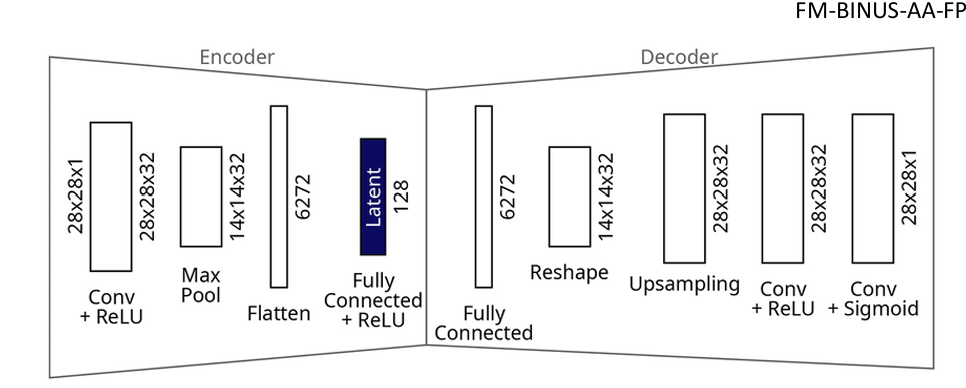

##  Baseline Autoencoder

Pada bagian ini saya membangun model **Baseline Autoencoder** sesuai dengan arsitektur yang diberikan pada soal. Model terdiri dari dua bagian, yaitu **encoder** dan **decoder**. Encoder bertugas mengubah citra menjadi representasi yang lebih kecil dengan dimensi **128**, sedangkan decoder bertugas merekonstruksi kembali citra sehingga hasil keluarannya semirip mungkin dengan citra asli. Setelah model selesai dilatih, kualitas citra hasil rekonstruksi akan dievaluasi menggunakan **Structural Similarity Index (SSIM)** pada data testing.

## Baseline Autoencoder

Pada bagian ini saya membangun model **Baseline Autoencoder** sesuai dengan arsitektur yang diberikan pada soal. Model terdiri dari dua bagian, yaitu **encoder** dan **decoder**. Encoder bertugas mengubah citra menjadi representasi yang lebih kecil dengan dimensi **128**, sedangkan decoder bertugas merekonstruksi kembali citra sehingga hasil keluarannya semirip mungkin dengan citra asli. Setelah model selesai dilatih, kualitas citra hasil rekonstruksi akan dievaluasi menggunakan **Structural Similarity Index (SSIM)** pada data testing.

In [ ]:
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1600, 28, 28, 1)
(200, 28, 28, 1)
(200, 28, 28, 1)


### Baseline Autoencoder

Pada tahap ini saya membangun model **Baseline Autoencoder** sesuai dengan arsitektur yang diberikan pada soal. Model terdiri dari dua bagian, yaitu **encoder** dan **decoder**. Encoder berfungsi mengubah citra menjadi representasi berdimensi **128**, sedangkan decoder bertugas merekonstruksi kembali citra sehingga hasilnya semirip mungkin dengan citra asli. Setelah model selesai dilatih, kualitas hasil rekonstruksi akan dievaluasi menggunakan **Structural Similarity Index (SSIM)** pada data testing.

### Import Library

Sebelum membangun model Autoencoder, saya mengimpor beberapa library dari **TensorFlow Keras** yang akan digunakan pada proses pembuatan model. Setiap layer memiliki fungsi yang berbeda, mulai dari menerima input, mengekstrak fitur pada gambar, mengurangi ukuran data, hingga merekonstruksi kembali gambar hasil decoder. Selain itu, saya juga mengimpor `plot_model` untuk menampilkan diagram arsitektur model agar lebih mudah dipahami.

In [ ]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    Flatten,
    Dense,
    Reshape
)

from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model

Library yang digunakan pada bagian ini adalah:

- **Input** : menentukan bentuk data masukan.
- **Conv2D** : mengekstrak fitur dari citra.
- **MaxPooling2D** : mengurangi ukuran feature map.
- **Flatten** : mengubah feature map menjadi vektor.
- **Dense** : membentuk representasi data menjadi 128 fitur.
- **Reshape** : mengembalikan vektor menjadi feature map.
- **UpSampling2D** : memperbesar kembali ukuran feature map.
- **Model** : menggabungkan seluruh layer menjadi model Autoencoder.
- **plot_model** : menampilkan diagram arsitektur model.

### Encoder

Pada bagian ini saya membuat **encoder**, yaitu bagian yang bertugas mengambil informasi penting dari gambar dan mengurangi dimensinya. Sesuai dengan arsitektur pada soal, gambar akan diproses menggunakan **Conv2D**, kemudian ukurannya diperkecil dengan **MaxPooling**. Setelah itu data diubah menjadi satu dimensi (*flatten*) dan dipadatkan menjadi **128 fitur** sebagai hasil dari proses *dimension reduction*.

In [ ]:
# Encoder
input_img = Input(shape=(28, 28, 1), name="Input")

x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation="relu",
    padding="same",
    name="Encoder_Conv"
)(input_img)

x = MaxPooling2D(
    pool_size=(2,2),
    padding="same",
    name="Encoder_MaxPool"
)(x)

x = Flatten(name="Flatten")(x)

latent = Dense(
    128,
    activation="relu",
    name="Latent_128"
)(x)

### Decoder

Setelah encoder menghasilkan representasi berdimensi **128**, langkah berikutnya adalah membangun **decoder**. Decoder bertugas mengubah kembali representasi tersebut menjadi gambar dengan ukuran **28 × 28 × 1**. Tujuannya adalah agar hasil rekonstruksi memiliki bentuk yang sama dan semirip mungkin dengan gambar aslinya.

In [ ]:
x = Dense(
    14 * 14 * 32,
    activation="relu",
    name="Decoder_Dense"
)(latent)

x = Reshape(
    (14,14,32),
    name="Reshape"
)(x)

x = UpSampling2D(
    size=(2,2),
    name="UpSampling"
)(x)

x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation="relu",
    padding="same",
    name="Decoder_Conv"
)(x)

output = Conv2D(
    filters=1,
    kernel_size=(3,3),
    activation="sigmoid",
    padding="same",
    name="Output"
)(x)

### Autoencoder Model

Setelah encoder dan decoder selesai dibuat, keduanya digabungkan menjadi satu model **Autoencoder**. Model ini akan menerima gambar sebagai input, kemudian menghasilkan gambar hasil rekonstruksi sebagai output. Selanjutnya saya akan melihat ringkasan arsitektur model untuk memastikan bahwa seluruh layer sudah sesuai dengan arsitektur yang diminta pada soal.

In [ ]:
autoencoder = Model(
    inputs=input_img,
    outputs=output,
    name="Baseline_Autoencoder"
)

autoencoder.summary()

Model: "Baseline_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Conv (Conv2D)           │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_MaxPool (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_128 (Dense)              │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Dense (Dense)           │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reshape (Reshape)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ UpSampling (UpSampling2D)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Conv (Conv2D)           │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Conv2D)                 │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,889 (6.19 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

### \Arsitektur Model

Setelah model selesai dibuat, saya menampilkan ringkasan arsitektur untuk memastikan setiap layer sudah sesuai dengan arsitektur baseline pada soal, termasuk proses *dimension reduction* dari **784 fitur** menjadi **128 fitur**.

In [ ]:
autoencoder.summary()

Model: "Baseline_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Conv (Conv2D)           │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_MaxPool (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_128 (Dense)              │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Dense (Dense)           │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reshape (Reshape)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ UpSampling (UpSampling2D)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Conv (Conv2D)           │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Conv2D)                 │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865,669 (18.56 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,243,780 (12.37 MB)

Berdasarkan hasil model summary, arsitektur Autoencoder berhasil dibuat sesuai dengan gambar pada soal...

### Dimension Reduction

Model ini mengurangi ukuran data dari **784 fitur** menjadi **128 fitur**. Tujuannya agar informasi penting pada gambar tetap dipertahankan dengan ukuran data yang lebih kecil.

### Compile Model

Sebelum model dilatih, saya perlu menentukan **optimizer** dan **loss function** yang akan digunakan. Pada model ini saya menggunakan **Adam** karena dapat membantu proses pelatihan menjadi lebih stabil. Sedangkan **Binary Crossentropy** digunakan karena nilai piksel hasil normalisasi berada pada rentang **0–1** dan layer output menggunakan aktivasi **Sigmoid**.

In [ ]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

### Training Model

Setelah model selesai dibuat, langkah berikutnya adalah melatih model menggunakan data training. Selama proses pelatihan, saya juga menggunakan data validation untuk melihat apakah model semakin baik dalam merekonstruksi gambar dan untuk memantau performanya pada data yang tidak digunakan saat proses belajar.

In [ ]:
history = autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=20,
    batch_size=32,
    shuffle=True,
    verbose=1
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.6535 - val_loss: 0.6207
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.5909 - val_loss: 0.5861
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.5658 - val_loss: 0.5712
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.5530 - val_loss: 0.5616
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.5454 - val_loss: 0.5547
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.5403 - val_loss: 0.5508
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.5356 - val_loss: 0.5475
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.5331 - val_loss: 0.5457
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.5308 - val_loss: 0.5435
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.5282 - val_loss: 0.5421
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.5267 - val_loss: 0.5416
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.5

Karena Autoencoder termasuk model **unsupervised learning**, maka target yang digunakan sama dengan data masukannya. Artinya, model belajar untuk menghasilkan kembali gambar yang sama seperti gambar asli setelah melewati proses *dimension reduction*.

### Training Result

Setelah proses pelatihan selesai, saya menampilkan perubahan nilai **training loss** dan **validation loss** pada setiap epoch. Grafik ini digunakan untuk melihat apakah model belajar dengan baik selama proses pelatihan.

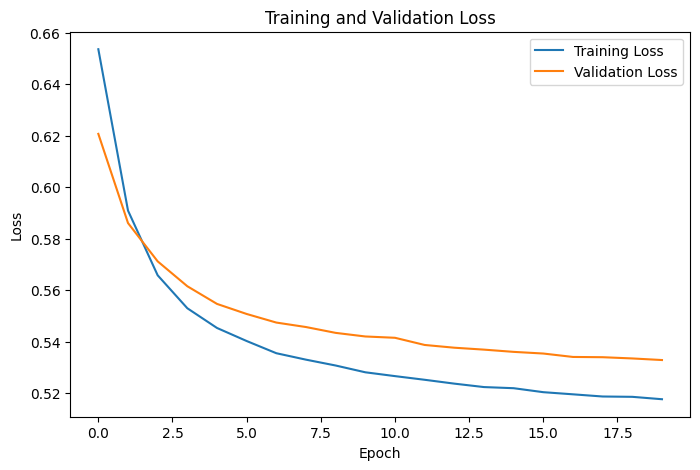

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Training Loss dan Validation Loss

Setelah proses pelatihan selesai, saya melihat perubahan nilai **training loss** dan **validation loss** pada setiap epoch. Grafik ini digunakan untuk mengetahui apakah model belajar dengan baik selama proses pelatihan serta membandingkan performa model pada data training dan validation.

### Hasil Rekonstruksi Gambar

Sebelum menghitung nilai SSIM, saya menampilkan beberapa contoh gambar asli dan hasil rekonstruksi dari Autoencoder. Tujuannya untuk melihat secara langsung seberapa baik model mampu membangun kembali gambar setelah melalui proses *dimension reduction*.

In [ ]:
# Reconstruct test images
decoded_images = autoencoder.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


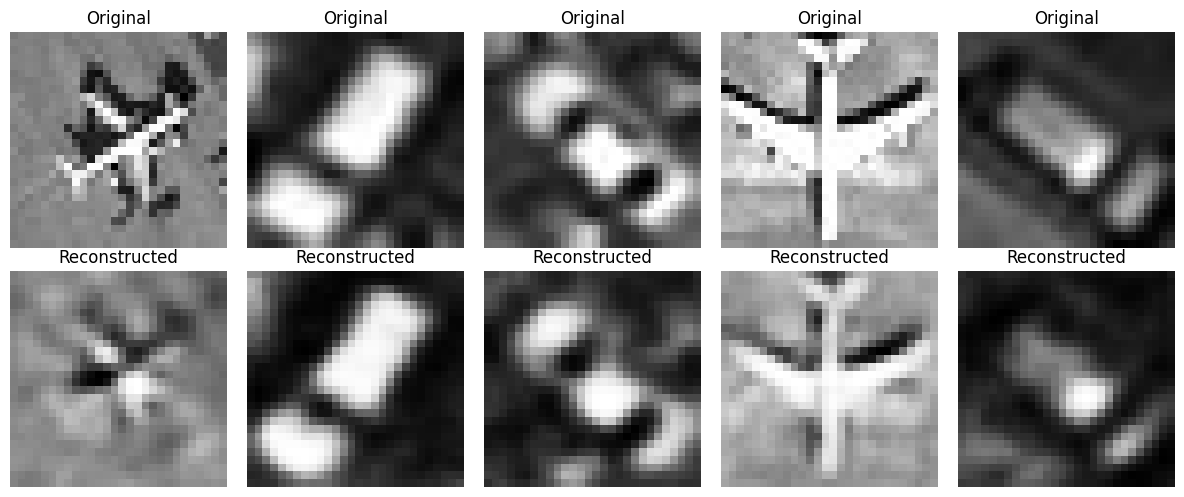

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n = 5

plt.figure(figsize=(12,5))

for i in range(n):

    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_images[i].reshape(28,28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

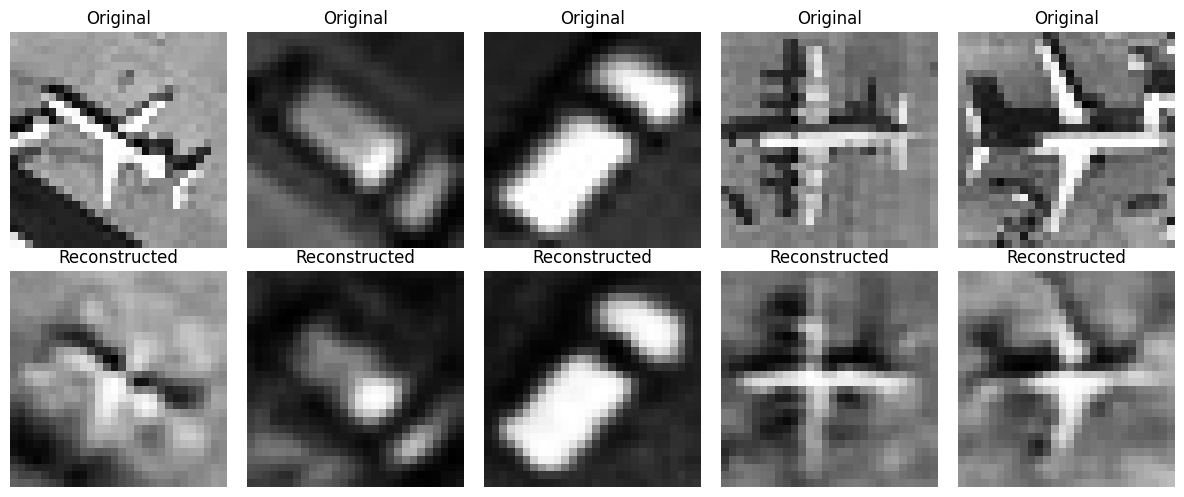

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n = 5
random_idx = np.random.choice(len(X_test), n, replace=False)

plt.figure(figsize=(12,5))

for i, idx in enumerate(random_idx):

    # Original Image
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[idx].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed Image
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_images[idx].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

Berdasarkan hasil di atas, gambar hasil rekonstruksi sudah memiliki bentuk yang mirip dengan gambar asli. Meskipun masih terlihat sedikit lebih halus atau blur, objek utama seperti mobil dan pesawat masih dapat dikenali dengan baik. Selanjutnya, kualitas hasil rekonstruksi akan diukur menggunakan **Structural Similarity Index (SSIM)** agar diperoleh hasil yang lebih objektif.

### Evaluasi Menggunakan Structural Similarity Index (SSIM)

Setelah melihat hasil rekonstruksi secara visual, saya melakukan evaluasi menggunakan **Structural Similarity Index (SSIM)** pada seluruh data testing. SSIM digunakan untuk mengukur tingkat kemiripan antara gambar asli dan gambar hasil rekonstruksi. Nilai SSIM berada pada rentang **0 sampai 1**, di mana nilai yang semakin mendekati **1** menunjukkan bahwa hasil rekonstruksi semakin mirip dengan gambar asli.

In [ ]:
from skimage.metrics import structural_similarity as ssim

In [ ]:
ssim_scores = []

for i in range(len(X_test)):

    score = ssim(
        X_test[i].squeeze(),
        decoded_images[i].squeeze(),
        data_range=1.0
    )

    ssim_scores.append(score)

ssim_scores = np.array(ssim_scores)

In [ ]:
print("="*50)
print("SSIM EVALUATION")
print("="*50)

print(f"Average SSIM : {ssim_scores.mean():.4f}")
print(f"Highest SSIM : {ssim_scores.max():.4f}")
print(f"Lowest SSIM  : {ssim_scores.min():.4f}")

SSIM EVALUATION
Average SSIM : 0.7225
Highest SSIM : 0.9481
Lowest SSIM  : 0.3630


### Evaluasi SSIM

Model mendapatkan **rata-rata SSIM sebesar 0.7225**, yang berarti hasil rekonstruksi sudah cukup mirip dengan gambar aslinya. Beberapa gambar bahkan memiliki hasil yang sangat baik dengan nilai SSIM tertinggi **0.9481**, sedangkan beberapa gambar lainnya masih kurang baik sehingga nilai SSIM terendahnya **0.3630**.

Nilai ini masih **wajar** karena model yang digunakan masih berupa **baseline Autoencoder** dengan arsitektur sederhana. Selain itu, gambar diperkecil dari **784 fitur menjadi 128 fitur**, sehingga tidak semua informasi pada gambar bisa dipertahankan. Meskipun begitu, model sudah mampu merekonstruksi gambar dengan cukup baik dan hasil ini bisa dijadikan sebagai **baseline** untuk tahap selanjutnya.

In [ ]:
# =============================================
# SSIM per kelas — Car vs Plane
# =============================================

ssim_car   = []
ssim_plane = []

for i in range(len(X_test)):
    score = ssim(
        X_test[i].squeeze(),
        decoded_images[i].squeeze(),
        data_range=1.0
    )
    if y_test[i] == 0:          # 0 = Car
        ssim_car.append(score)
    else:                        # 1 = Plane
        ssim_plane.append(score)

ssim_car   = np.array(ssim_car)
ssim_plane = np.array(ssim_plane)

print("=" * 45)
print("SSIM PER KELAS — BASELINE MODEL")
print("=" * 45)
print(f"Car   — Rata-rata SSIM : {ssim_car.mean():.4f}")
print(f"Car   — Tertinggi SSIM : {ssim_car.max():.4f}")
print(f"Car   — Terendah  SSIM : {ssim_car.min():.4f}")
print()
print(f"Plane — Rata-rata SSIM : {ssim_plane.mean():.4f}")
print(f"Plane — Tertinggi SSIM : {ssim_plane.max():.4f}")
print(f"Plane — Terendah  SSIM : {ssim_plane.min():.4f}")

SSIM PER KELAS — BASELINE MODEL
Car   — Rata-rata SSIM : 0.8377
Car   — Tertinggi SSIM : 0.9481
Car   — Terendah  SSIM : 0.5370

Plane — Rata-rata SSIM : 0.6074
Plane — Tertinggi SSIM : 0.8771
Plane — Terendah  SSIM : 0.3630


## Analisis SSIM per Kelas

Dari hasil di atas, kita bisa lihat apakah model lebih mudah merekonstruksi **Car** atau **Plane**.

Kemungkinan yang terjadi:
- Kalau SSIM **Plane lebih tinggi**: artinya pesawat lebih mudah direkonstruksi karena
  bentuknya lebih "khas" (ada sayap yang jelas) sehingga autoencoder lebih gampang
  menangkap polanya
- Kalau SSIM **Car lebih tinggi**: artinya mobil lebih seragam bentuknya dari atas,
  sehingga encoder lebih mudah mengkompresi informasinya

Perbedaan ini penting untuk memahami **batas kemampuan model baseline** sebelum kita
coba perbaiki di bagian 2C.

### Kesimpulan

Pada bagian ini, saya berhasil membangun **baseline Autoencoder** yang dapat mengurangi dimensi gambar dari **784 fitur menjadi 128 fitur**. Setelah dilatih, model mampu merekonstruksi kembali gambar dengan cukup baik, yang ditunjukkan oleh **rata-rata SSIM sebesar 0.7225**. Hasil ini menunjukkan bahwa model sudah dapat mempertahankan informasi penting pada gambar dan dapat dijadikan sebagai **baseline** untuk dibandingkan dengan model yang akan dikembangkan pada tahap berikutnya.

## Strategi Modifikasi Arsitektur

Setelah mendapatkan hasil baseline dengan SSIM **0.7225**, saya akan mencoba beberapa
modifikasi arsitektur untuk mendapatkan hasil yang lebih optimal.

### Landasan Teori Setiap Modifikasi

Berikut alasan teoritis di balik setiap perubahan yang akan saya dicoba:


**1. Menambah Conv Layer (Deeper Encoder)**
- Conv layer yang lebih dalam bisa menangkap **fitur hierarkis** dari gambar
- Layer pertama biasanya menangkap tepi/garis, layer kedua menangkap bentuk yang lebih kompleks
- Untuk gambar overhead (Car & Plane), fitur seperti sayap pesawat dan bodi mobil
  butuh beberapa level abstraksi

**2. Menambah Dense Layer di Bottleneck (256 ->128)**
- Menambah layer Dense sebelum latent space 128 berfungsi sebagai **penyaringan fitur bertahap**
- Daripada langsung dari 6272 -> 128 (lompatan terlalu besar), dibuat 6272 -> 256 -> 128
- Ini lebih mudah dioptimasi karena gradiensnya lebih stabil

**3. Batch Normalization**
- Batch Norm membantu **menstabilkan distribusi aktivasi** di setiap layer
- Ini bisa mempercepat training dan mengurangi sensitivitas terhadap learning rate
- *Catatan: pada dataset kecil, Batch Norm kadang justru memperburuk hasil karena
  statistik batch tidak representatif*

**4. Dropout**
- Dropout mencegah **overfitting** dengan mematikan neuron secara acak saat training
- Tapi untuk tugas rekonstruksi (autoencoder), Dropout yang terlalu agresif bisa
  merusak informasi yang perlu dipertahankan

**5. Learning Rate Lebih Kecil (0.0005 vs default 0.001)**
- Learning rate lebih kecil ->update weight lebih hati-hati -> training lebih stabil
- Mencegah model "melompat" melewati titik optimal

**6. Early Stopping**
- Menghentikan training otomatis saat validation loss tidak membaik
- Mencegah overfitting dan menghemat waktu komputasi


Dari ke-6 teknik di atas, saya akan melakukan beberapa eksperimen kombinasi untuk
mencari arsitektur yang **paling optimal**.

### Import Library

Pada bagian ini saya mengimpor beberapa library tambahan yang digunakan untuk melakukan tuning hyperparameter selama proses training.

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

### Hyperparameter

Pada model ini saya melakukan beberapa perubahan pada hyperparameter dibandingkan model baseline. Tujuannya agar proses training lebih stabil dan model memiliki kesempatan untuk belajar lebih baik.

In [ ]:
learning_rate = 0.0005
batch_size = 16
epochs = 30

Perubahan hyperparameter yang digunakan adalah:

- **Learning Rate = 0.0005** agar proses update bobot lebih stabil.
- **Batch Size = 16** supaya model belajar dari data dalam kelompok yang lebih kecil.
- **Epoch = 30** agar model memiliki waktu belajar yang lebih banyak dibandingkan model baseline.

### Early Stopping

Saya menggunakan **Early Stopping** untuk menghentikan proses training jika nilai validation loss sudah tidak mengalami peningkatan. Cara ini membantu mencegah model belajar terlalu lama dan mengurangi risiko overfitting.

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

### Modifikasi Arsitektur Autoencoder

Pada model ini saya menambahkan beberapa layer pada bagian **encoder** dan **decoder**. Tujuannya agar model dapat mempelajari lebih banyak fitur dari gambar sebelum melakukan proses *dimension reduction*. Meskipun arsitekturnya diubah, ukuran **latent space tetap 128 fitur** agar tetap bisa dibandingkan secara adil dengan model baseline pada nomor 2B.

In [ ]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    Flatten,
    Dense,
    Reshape
)

from tensorflow.keras.models import Model

### Encoder

Pada bagian encoder, saya menambahkan satu **Conv2D** dan satu **Dense Layer**. Dengan begitu, model memiliki kemampuan yang lebih baik dalam mempelajari pola pada gambar sebelum data diperkecil menjadi **128 fitur**.

In [ ]:
input_img = Input(shape=(28, 28, 1), name="Input")

# Encoder
x = Conv2D(32, (3,3), activation="relu", padding="same", name="Encoder_Conv1")(input_img)

x = Conv2D(64, (3,3), activation="relu", padding="same", name="Encoder_Conv2")(x)

x = MaxPooling2D((2,2), padding="same", name="Encoder_MaxPool")(x)

x = Flatten(name="Flatten")(x)

x = Dense(256, activation="relu", name="Dense_256")(x)

latent = Dense(128, activation="relu", name="Latent_128")(x)

### Decoder

Pada bagian decoder, saya juga menambahkan satu **Dense Layer** dan satu **Conv2D** agar model memiliki kemampuan yang lebih baik dalam membangun kembali gambar dari hasil *dimension reduction*.

In [ ]:
x = Dense(256, activation="relu", name="Decoder_Dense1")(latent)

x = Dense(14 * 14 * 64, activation="relu", name="Decoder_Dense2")(x)

x = Reshape((14,14,64), name="Reshape")(x)

x = UpSampling2D((2,2), name="UpSampling")(x)

x = Conv2D(64, (3,3), activation="relu", padding="same", name="Decoder_Conv1")(x)

x = Conv2D(32, (3,3), activation="relu", padding="same", name="Decoder_Conv2")(x)

output = Conv2D(
    1,
    (3,3),
    activation="sigmoid",
    padding="same",
    name="Output"
)(x)

In [ ]:
improved_autoencoder = Model(
    inputs=input_img,
    outputs=output,
    name="Improved_Autoencoder"
)

### Ringkasan Arsitektur Model

Setelah model selesai dibuat, saya menampilkan ringkasan arsitektur untuk memastikan perubahan yang dilakukan sudah sesuai dengan rancangan dan ukuran **latent space** tetap **128 fitur**.

In [ ]:
improved_autoencoder.summary()

Model: "Improved_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Conv1 (Conv2D)          │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Conv2 (Conv2D)          │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_MaxPool (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_256 (Dense)               │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_128 (Dense)              │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Dense1 (Dense)          │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Dense2 (Dense)          │ (None, 12544)          │     3,223,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reshape (Reshape)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ UpSampling (UpSampling2D)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Conv1 (Conv2D)          │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Conv2 (Conv2D)          │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Conv2D)                 │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,575,745 (25.08 MB)

 Trainable params: 6,575,745 (25.08 MB)

 Non-trainable params: 0 (0.00 B)

### Compile Model

Model kemudian di-*compile* menggunakan **Adam** dengan **learning rate 0.0005**. Nilai learning rate dibuat lebih kecil dibanding model baseline agar proses training lebih stabil. Loss function tetap menggunakan **Binary Crossentropy** karena nilai piksel sudah berada pada rentang **0–1**.

In [ ]:
optimizer = Adam(learning_rate=learning_rate)

improved_autoencoder.compile(
    optimizer=optimizer,
    loss="binary_crossentropy"
)

### Training Model

Setelah model selesai di-*compile*, langkah berikutnya adalah melatih model menggunakan **training set** dan memantau performanya pada **validation set**. Pada model ini digunakan **Early Stopping** agar proses training berhenti secara otomatis jika nilai **validation loss** sudah tidak mengalami peningkatan. Cara ini membantu mengurangi risiko overfitting dan menyimpan model dengan performa terbaik.

In [ ]:
history_improved = improved_autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 189ms/step - loss: 0.6380 - val_loss: 0.6093
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 194ms/step - loss: 0.5797 - val_loss: 0.5811
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 186ms/step - loss: 0.5615 - val_loss: 0.5692
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 188ms/step - loss: 0.5520 - val_loss: 0.5622
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 194ms/step - loss: 0.5453 - val_loss: 0.5576
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 186ms/step - loss: 0.5398 - val_loss: 0.5535
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 192ms/step - loss: 0.5350 - val_loss: 0.5520
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step - loss: 0.5313 - val_loss: 0.5485
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 194ms/step - loss: 0.5282 - val_loss: 0.5472
Epoch 10/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 189ms/step - loss: 0.5252 - val_loss: 0.5461
Epoch 11/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 205ms/step - loss: 0.5226 - val_loss: 0.5444
Epoch 12/30
100/100

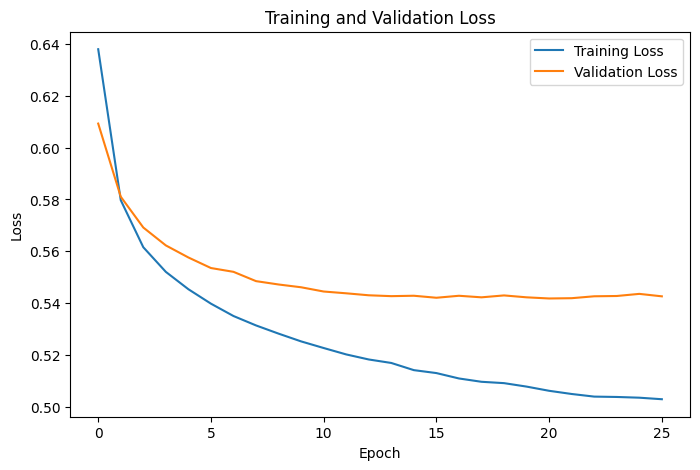

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_improved.history["loss"], label="Training Loss")
plt.plot(history_improved.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Hasil Training

Grafik di atas menunjukkan bahwa **training loss** dan **validation loss** sama-sama menurun selama proses training. Hal ini menandakan bahwa model berhasil belajar dari data dengan baik.

Di akhir training, **training loss** masih terus menurun, sedangkan **validation loss** mulai stabil di sekitar **0.542**. Ini menunjukkan bahwa model sudah mulai mencapai performa terbaik pada data validasi. Selain itu, jarak antara kedua kurva masih cukup wajar sehingga belum terlihat tanda **overfitting** yang berlebihan.

### Hasil Rekonstruksi

Setelah model selesai dilatih, saya membandingkan gambar asli dengan hasil rekonstruksi dari model yang telah dimodifikasi. Tujuannya untuk melihat secara langsung apakah kualitas hasil rekonstruksi menjadi lebih baik dibandingkan model baseline.

In [ ]:
decoded_images_improved = improved_autoencoder.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step


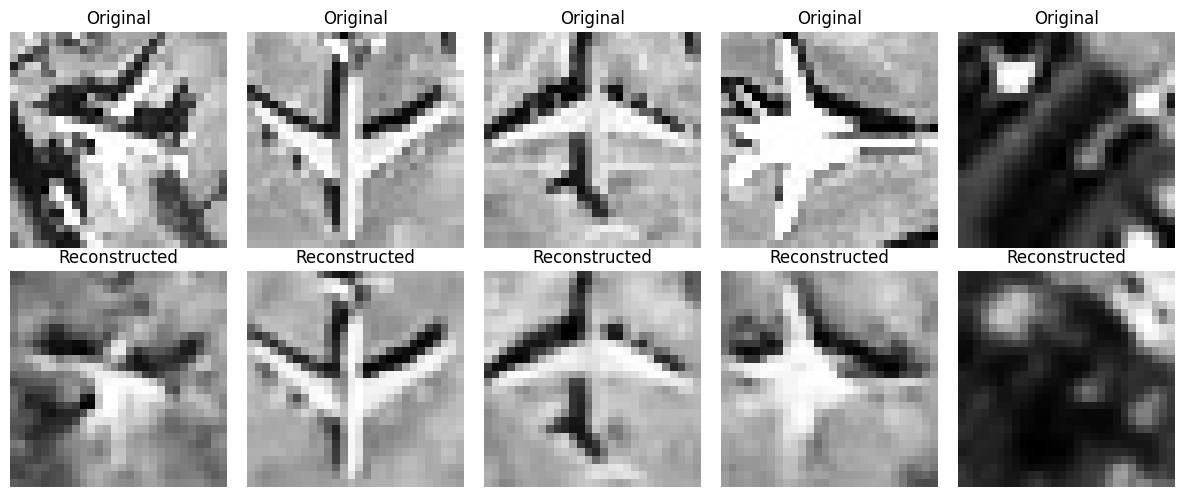

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n = 5

random_idx = np.random.choice(len(X_test), n, replace=False)

plt.figure(figsize=(12,5))

for i, idx in enumerate(random_idx):

    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[idx].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_images_improved[idx].reshape(28,28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Hasil Rekonstruksi

Dari hasil visualisasi di atas, model sudah mampu merekonstruksi bentuk utama gambar, seperti mobil dan pesawat. Namun, hasil rekonstruksi masih terlihat lebih halus dan sedikit buram dibandingkan gambar asli. Artinya, model sudah berhasil menangkap pola penting dari gambar, tetapi masih ada beberapa detail yang belum dapat dipertahankan dengan baik.

### Evaluasi Menggunakan SSIM

Selanjutnya saya menghitung nilai **Structural Similarity Index (SSIM)** pada seluruh data **test**. Nilai SSIM digunakan untuk mengukur tingkat kemiripan antara gambar asli dan hasil rekonstruksi. Semakin mendekati **1**, berarti kualitas rekonstruksi semakin baik.

In [ ]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

ssim_scores_improved = []

for i in range(len(X_test)):

    score = ssim(
        X_test[i].reshape(28,28),
        decoded_images_improved[i].reshape(28,28),
        data_range=1.0
    )

    ssim_scores_improved.append(score)

ssim_scores_improved = np.array(ssim_scores_improved)

In [ ]:
print("="*50)
print("SSIM EVALUATION")
print("="*50)

print(f"Average SSIM : {ssim_scores_improved.mean():.4f}")
print(f"Highest SSIM : {ssim_scores_improved.max():.4f}")
print(f"Lowest SSIM  : {ssim_scores_improved.min():.4f}")

SSIM EVALUATION
Average SSIM : 0.6769
Highest SSIM : 0.9206
Lowest SSIM  : 0.2875


### Evaluasi SSIM

Model menghasilkan **rata-rata SSIM sebesar 0.6769**. Nilai ini menunjukkan bahwa hasil rekonstruksi sudah cukup mirip dengan gambar asli, tetapi masih ada beberapa gambar yang kualitas rekonstruksinya kurang baik. Hal ini terlihat dari nilai SSIM terendah yang mencapai **0.2875**, sedangkan nilai tertingginya **0.9206**.

Jika dibandingkan dengan model **baseline**, nilai SSIM pada model ini masih lebih rendah. Artinya, modifikasi arsitektur dan hyperparameter yang digunakan belum berhasil meningkatkan kualitas rekonstruksi sehingga masih perlu dilakukan perbaikan.

### Distribusi Nilai SSIM

Grafik berikut menunjukkan sebaran nilai SSIM dari seluruh gambar pada data test. Dari grafik ini dapat dilihat apakah sebagian besar gambar memiliki nilai SSIM yang tinggi atau masih banyak yang rendah.

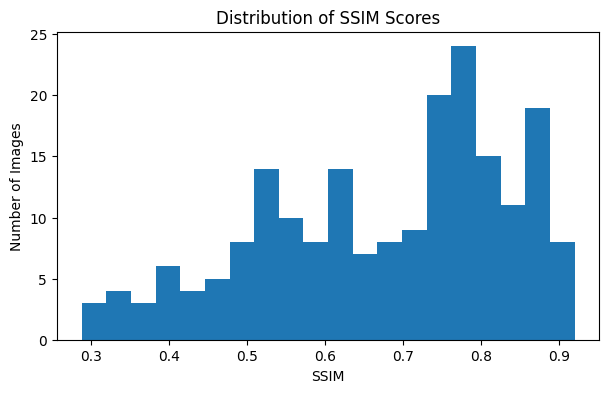

In [ ]:
plt.figure(figsize=(7,4))

plt.hist(ssim_scores_improved, bins=20)

plt.title("Distribution of SSIM Scores")
plt.xlabel("SSIM")
plt.ylabel("Number of Images")

plt.show()


Sebagian besar nilai SSIM berada pada rentang **0.7–0.8**, yang menunjukkan bahwa banyak gambar berhasil direkonstruksi dengan cukup baik. Namun, masih ada beberapa gambar dengan nilai SSIM rendah sehingga rata-rata SSIM keseluruhan belum lebih baik dibandingkan model baseline.

### Optimasi Arsitektur

Pada percobaan sebelumnya, model yang sudah dimodifikasi ternyata masih menghasilkan **nilai SSIM yang lebih rendah** dibandingkan model baseline. Hal ini menunjukkan bahwa perubahan arsitektur yang dilakukan belum berhasil meningkatkan kualitas rekonstruksi gambar.

Oleh karena itu, saya mencoba membuat arsitektur baru yang lebih efisien. Fokusnya bukan menambah jumlah layer atau parameter sebanyak mungkin, tetapi membuat model lebih baik dalam mempelajari fitur gambar. Dengan cara ini, diharapkan hasil *dimension reduction* menjadi lebih optimal dan nilai SSIM dapat meningkat.

### Perubahan Arsitektur

Beberapa perubahan yang dilakukan pada model ini adalah:

- Menambahkan **Convolution Layer** sebelum proses MaxPooling agar model dapat mempelajari lebih banyak fitur gambar.
- Menambahkan **Batch Normalization** agar proses training lebih stabil.
- Menambahkan **Dropout** untuk mengurangi risiko overfitting.
- Tetap mempertahankan ukuran **latent space sebesar 128 fitur** agar sesuai dengan ketentuan soal.

In [ ]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    Flatten,
    Dense,
    Reshape,
    BatchNormalization,
    Dropout
)

from tensorflow.keras.models import Model

### Encoder

Pada encoder saya tetap menggunakan alur yang sama seperti model baseline. Perbedaannya, saya menambahkan satu **Convolution Layer** untuk mengambil fitur yang lebih banyak serta **Batch Normalization** agar proses training lebih stabil. Selain itu, **Dropout** digunakan untuk membantu mengurangi overfitting.

In [ ]:
input_img = Input(shape=(28,28,1), name="Input")

x = Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same",
    name="Encoder_Conv1"
)(input_img)

x = BatchNormalization(name="BN1")(x)

x = Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same",
    name="Encoder_Conv2"
)(x)

x = MaxPooling2D(
    (2,2),
    padding="same",
    name="Encoder_MaxPool"
)(x)

x = Flatten(name="Flatten")(x)

x = Dropout(0.2, name="Dropout")(x)

latent = Dense(
    128,
    activation="relu",
    name="Latent_128"
)(x)

### Decoder

Bagian decoder tetap mengikuti arsitektur dasar pada soal. Saya menambahkan **Batch Normalization** setelah proses konvolusi agar hasil rekonstruksi menjadi lebih stabil, kemudian menghasilkan citra keluaran menggunakan fungsi aktivasi **Sigmoid**.

In [ ]:
x = Dense(
    14*14*32,
    activation="relu",
    name="Decoder_Dense"
)(latent)

x = Reshape(
    (14,14,32),
    name="Reshape"
)(x)

x = UpSampling2D(
    (2,2),
    name="UpSampling"
)(x)

x = Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same",
    name="Decoder_Conv"
)(x)

x = BatchNormalization(name="BN2")(x)

output = Conv2D(
    1,
    (3,3),
    activation="sigmoid",
    padding="same",
    name="Output"
)(x)

In [ ]:
optimized_autoencoder = Model(
    input_img,
    output,
    name="Optimized_Autoencoder"
)

In [ ]:
optimized_autoencoder.summary()

Model: "Optimized_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Conv1 (Conv2D)          │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN1 (BatchNormalization)        │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Conv2 (Conv2D)          │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_MaxPool (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_128 (Dense)              │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Dense (Dense)           │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reshape (Reshape)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ UpSampling (UpSampling2D)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Conv (Conv2D)           │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN2 (BatchNormalization)        │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Conv2D)                 │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,631,393 (6.22 MB)

 Trainable params: 1,631,265 (6.22 MB)

 Non-trainable params: 128 (512.00 B)

### Ringkasan Arsitektur

Model berhasil dibuat dengan ukuran **latent space 128 fitur** sesuai dengan ketentuan soal. Dibandingkan model baseline, arsitektur ini tetap mempertahankan alur utama Autoencoder, tetapi ditambahkan beberapa layer untuk membantu model mempelajari fitur gambar dengan lebih baik dan membuat proses training lebih stabil.

### Compile Model

Model kemudian di-*compile* menggunakan **Adam** dengan **learning rate 0.0005**. Nilai learning rate dibuat lebih kecil agar proses training lebih stabil. Loss function tetap menggunakan **Binary Crossentropy** karena nilai piksel sudah berada pada rentang **0–1**.

In [ ]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0005)

optimized_autoencoder.compile(
    optimizer=optimizer,
    loss="binary_crossentropy"
)

### Training Model

Setelah model selesai di-*compile*, langkah berikutnya adalah melatih model menggunakan **training set** dan mengevaluasi performanya pada **validation set**. Selain itu, digunakan **Early Stopping** agar proses training berhenti secara otomatis jika performa model sudah tidak meningkat. Cara ini membantu mengurangi risiko overfitting dan menyimpan model terbaik.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_optimized = optimized_autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - loss: 0.6211 - val_loss: 0.6881
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - loss: 0.5815 - val_loss: 0.6888
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - loss: 0.5711 - val_loss: 0.6987
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 0.5651 - val_loss: 0.6835
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - loss: 0.5616 - val_loss: 0.6180
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - loss: 0.5589 - val_loss: 0.5898
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - loss: 0.5567 - val_loss: 0.5689
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.5557 - val_loss: 0.5673
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - loss: 0.5554 - val_loss: 0.5664
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 0.5523 - val_loss: 0.5662
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.5508 - val_loss: 0.5645
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━

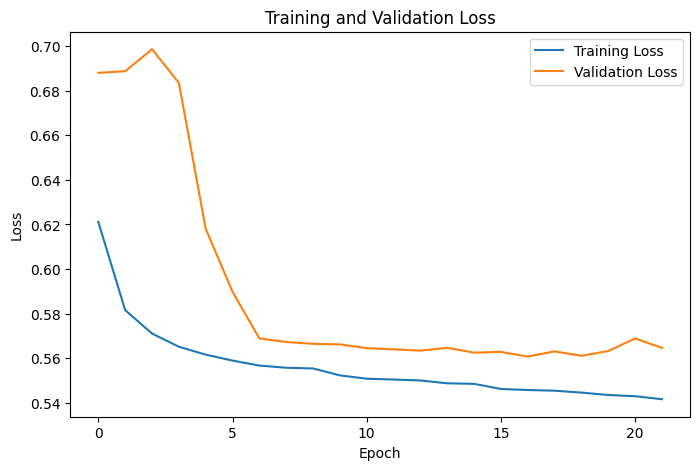

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_optimized.history["loss"], label="Training Loss")
plt.plot(history_optimized.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Hasil Training

Grafik menunjukkan bahwa **training loss** dan **validation loss** sama-sama turun selama proses training. Di awal training, nilai validation loss sempat tinggi, tetapi setelah beberapa epoch mulai turun dan menjadi lebih stabil.

Perbedaan antara training loss dan validation loss juga tidak terlalu jauh. Artinya, model sudah belajar dengan cukup baik dan belum menunjukkan tanda overfitting yang berlebihan. Selanjutnya, kualitas model akan dilihat dari hasil rekonstruksi gambar dan nilai **SSIM** pada data test.

### Hasil Rekonstruksi Gambar

Berikut adalah perbandingan beberapa gambar asli dengan hasil rekonstruksi dari model yang sudah dimodifikasi. Visualisasi ini membantu melihat apakah model mampu mempertahankan bentuk utama objek setelah proses *dimension reduction*.

In [ ]:
optimized_decoded = optimized_autoencoder.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step


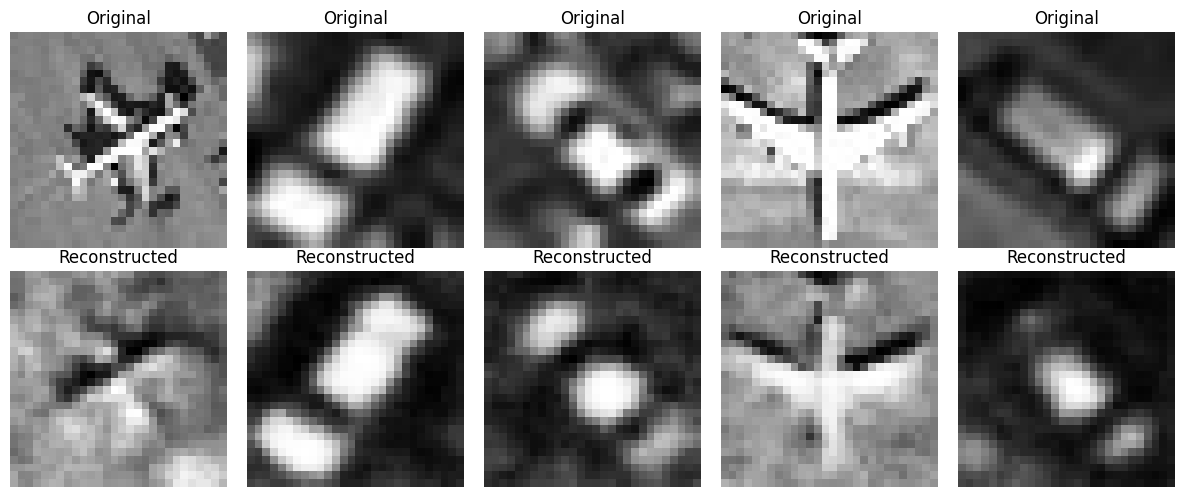

In [ ]:
import matplotlib.pyplot as plt

n = 5

plt.figure(figsize=(12,5))

for i in range(n):

    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(optimized_decoded[i].reshape(28,28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Hasil Rekonstruksi Gambar

Dari hasil di atas, gambar hasil rekonstruksi masih mempertahankan bentuk utama objek, baik mobil maupun pesawat. Walaupun hasilnya sedikit lebih blur dibanding gambar asli, objek masih mudah dikenali.

Hal ini menunjukkan bahwa model masih mampu menyimpan informasi penting ketika gambar diperkecil menjadi **128 fitur**, kemudian membangunnya kembali menjadi ukuran semula. Selanjutnya, kualitas rekonstruksi akan diukur secara objektif menggunakan **Structural Similarity Index (SSIM)**.

In [ ]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

ssim_scores = []

for i in range(len(X_test)):

    score = ssim(
        X_test[i].reshape(28,28),
        optimized_decoded[i].reshape(28,28),
        data_range=1.0
    )

    ssim_scores.append(score)

ssim_scores = np.array(ssim_scores)

In [ ]:
print("="*50)
print("SSIM EVALUATION")
print("="*50)

print(f"Average SSIM : {ssim_scores.mean():.4f}")
print(f"Highest SSIM : {ssim_scores.max():.4f}")
print(f"Lowest SSIM  : {ssim_scores.min():.4f}")

SSIM EVALUATION
Average SSIM : 0.5444
Highest SSIM : 0.8746
Lowest SSIM  : 0.0796


### Evaluasi SSIM

Model ini mendapatkan **rata-rata SSIM sebesar 0.5444**, dengan nilai tertinggi **0.8746** dan nilai terendah **0.0796**.

Kalau dibandingkan dengan model sebelumnya, hasilnya justru lebih rendah. Artinya, perubahan arsitektur yang saya coba belum berhasil membuat hasil rekonstruksi menjadi lebih baik.

Kemungkinan hal ini terjadi karena penambahan **Batch Normalization** dan **Dropout** membuat model kehilangan sebagian informasi gambar. Selain itu, jumlah data yang tidak terlalu banyak juga membuat model yang lebih kompleks jadi kurang cocok.

Dari hasil ini bisa disimpulkan kalau model yang lebih rumit belum tentu memberikan hasil yang lebih bagus. Karena itu, perlu dilakukan **tuning hyperparameter** untuk mencari kombinasi yang paling optimal.

## Optimasi Arsitektur Tahap Kedua

Hasil percobaan sebelumnya menunjukkan bahwa nilai SSIM justru turun setelah ditambahkan **Batch Normalization** dan **Dropout**. Artinya, perubahan tersebut belum cocok untuk dataset yang digunakan.

Karena itu, saya mencoba melakukan modifikasi lagi. Kali ini saya tetap mempertahankan arsitektur dasar Autoencoder, tetapi menghapus layer yang membuat performa menurun. Tujuannya supaya model bisa belajar lebih baik dan menghasilkan nilai SSIM yang lebih tinggi.

### Perubahan yang Dilakukan

Pada percobaan ini saya melakukan beberapa perubahan, yaitu:

- Menghapus **Batch Normalization**.
- Menghapus **Dropout**.
- Tetap menggunakan **2 Convolution Layer** agar model bisa mengambil fitur gambar lebih banyak.
- Tetap mempertahankan **latent space 128 fitur** sesuai soal.
- Tetap menggunakan **Early Stopping** dan **hyperparameter tuning**.

In [ ]:
input_img = Input(shape=(28,28,1), name="Input")

x = Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same",
    name="Encoder_Conv1"
)(input_img)

x = Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same",
    name="Encoder_Conv2"
)(x)

x = MaxPooling2D(
    (2,2),
    padding="same",
    name="Encoder_MaxPool"
)(x)

x = Flatten(name="Flatten")(x)

latent = Dense(
    128,
    activation="relu",
    name="Latent_128"
)(x)

### Encoder

Pada encoder saya tetap memakai dua **Convolution Layer** supaya model bisa mengambil lebih banyak fitur dari gambar sebelum diperkecil menjadi **128 fitur**. Dibandingkan percobaan sebelumnya, **Batch Normalization** dan **Dropout** dihapus karena hasilnya membuat nilai SSIM turun.

In [ ]:
x = Dense(
    14*14*32,
    activation="relu",
    name="Decoder_Dense"
)(latent)

x = Reshape(
    (14,14,32),
    name="Reshape"
)(x)

x = UpSampling2D(
    (2,2),
    name="UpSampling"
)(x)

x = Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same",
    name="Decoder_Conv"
)(x)

output = Conv2D(
    1,
    (3,3),
    activation="sigmoid",
    padding="same",
    name="Output"
)(x)

### Decoder

Decoder digunakan untuk membangun kembali gambar dari hasil **dimension reduction**. Strukturnya tetap sederhana agar model lebih fokus menghasilkan gambar yang mirip dengan gambar asli.

In [ ]:
optimized_v2 = Model(
    input_img,
    output,
    name="Optimized_Autoencoder_V2"
)

optimized_v2.summary()

Model: "Optimized_Autoencoder_V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Conv1 (Conv2D)          │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Conv2 (Conv2D)          │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_MaxPool (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_128 (Dense)              │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Dense (Dense)           │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reshape (Reshape)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ UpSampling (UpSampling2D)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Conv (Conv2D)           │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Conv2D)                 │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,631,137 (6.22 MB)

 Trainable params: 1,631,137 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

### Ringkasan Arsitektur

Model ini masih mengikuti arsitektur utama pada soal, tetapi dilakukan sedikit perbaikan berdasarkan hasil percobaan sebelumnya. Layer yang membuat performa menurun dihapus, sedangkan **Convolution Layer** tambahan tetap dipertahankan agar model tetap bisa mengambil fitur gambar dengan lebih baik.

### Ringkasan Arsitektur

Model ini masih mengikuti arsitektur utama pada soal, tetapi dilakukan sedikit perbaikan berdasarkan hasil percobaan sebelumnya. Layer yang membuat performa menurun dihapus, sedangkan **Convolution Layer** tambahan tetap dipertahankan agar model tetap bisa mengambil fitur gambar dengan lebih baik.

In [ ]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0005)

optimized_v2.compile(
    optimizer=optimizer,
    loss="binary_crossentropy"
)

### Training Model

Model kemudian dilatih menggunakan **training set** dan dievaluasi menggunakan **validation set**. Selain itu, digunakan **Early Stopping** agar training berhenti otomatis ketika **validation loss** sudah tidak membaik. Cara ini membantu mengurangi overfitting dan menyimpan model terbaik.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_optimized_v2 = optimized_v2.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 0.6352 - val_loss: 0.6028
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - loss: 0.5712 - val_loss: 0.5717
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - loss: 0.5511 - val_loss: 0.5576
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 0.5398 - val_loss: 0.5492
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - loss: 0.5334 - val_loss: 0.5442
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - loss: 0.5290 - val_loss: 0.5404
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - loss: 0.5258 - val_loss: 0.5377
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 0.5233 - val_loss: 0.5360
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 0.5212 - val_loss: 0.5341
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 0.5192 - val_loss: 0.5324
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.5179 - val_loss: 0.5309
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━━

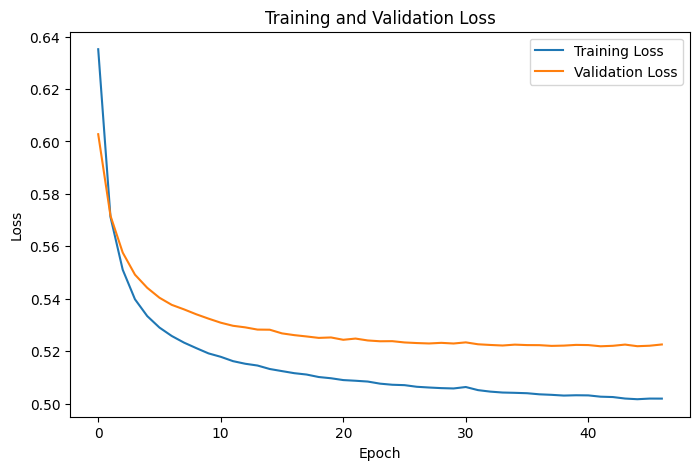

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_optimized_v2.history["loss"], label="Training Loss")
plt.plot(history_optimized_v2.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Hasil Training

Dari grafik terlihat kalau **training loss** dan **validation loss** sama-sama turun selama proses training. Ini berarti model berhasil belajar dari data.

Di akhir training, **validation loss** mulai stabil dan jaraknya tidak terlalu jauh dengan **training loss**. Artinya, model belajar dengan cukup baik dan belum menunjukkan overfitting yang berlebihan.

Secara keseluruhan, hasil training pada percobaan ini lebih stabil dibandingkan percobaan sebelumnya.

In [ ]:
optimized_v2_decoded = optimized_v2.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step


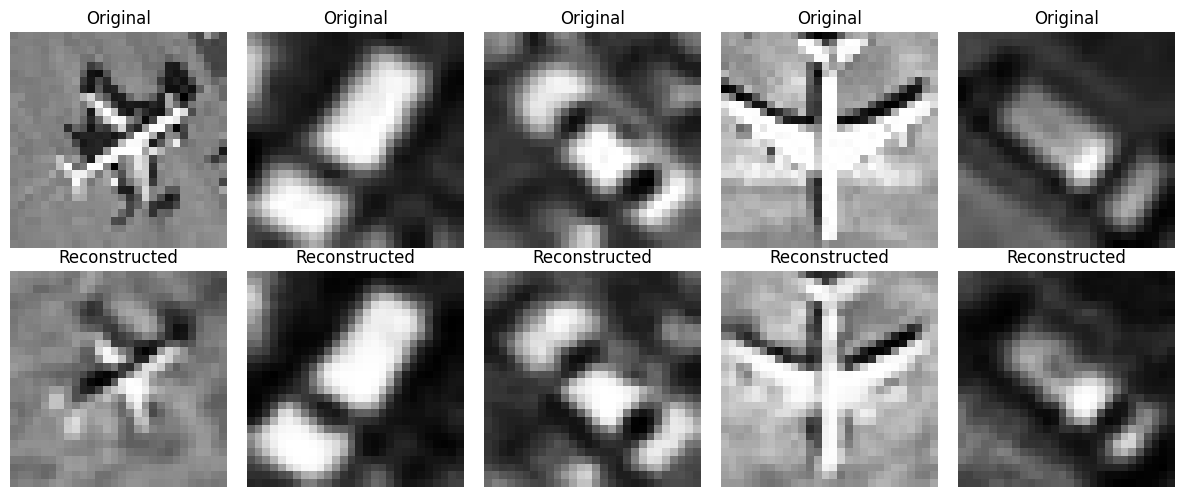

In [ ]:
import matplotlib.pyplot as plt

n = 5

plt.figure(figsize=(12,5))

for i in range(n):

    # Gambar asli
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Hasil rekonstruksi
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(optimized_v2_decoded[i].reshape(28,28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Hasil Rekonstruksi

Dari gambar di atas, hasil rekonstruksi sudah cukup mirip dengan gambar aslinya. Bentuk utama objek masih terlihat, walaupun beberapa bagian terlihat lebih halus atau sedikit blur.

Kalau dibandingkan dengan percobaan sebelumnya, hasil rekonstruksi pada model ini terlihat lebih jelas. Ini menunjukkan bahwa perubahan arsitektur dan hyperparameter membantu model dalam mempertahankan informasi penting dari gambar.

In [ ]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

ssim_scores_v2 = []

for i in range(len(X_test)):
    score = ssim(
        X_test[i].reshape(28,28),
        optimized_v2_decoded[i].reshape(28,28),
        data_range=1.0
    )
    ssim_scores_v2.append(score)

ssim_scores_v2 = np.array(ssim_scores_v2)

In [ ]:
print("="*50)
print("SSIM EVALUATION")
print("="*50)

print(f"Average SSIM : {ssim_scores_v2.mean():.4f}")
print(f"Highest SSIM : {ssim_scores_v2.max():.4f}")
print(f"Lowest SSIM  : {ssim_scores_v2.min():.4f}")

SSIM EVALUATION
Average SSIM : 0.8091
Highest SSIM : 0.9697
Lowest SSIM  : 0.5087


### Evaluasi SSIM

Model ini mendapatkan **rata-rata SSIM sebesar 0.8091**, dengan nilai tertinggi **0.9697** dan nilai terendah **0.5087**.

Kalau dibandingkan dengan semua percobaan sebelumnya, model ini memberikan hasil yang paling baik. Artinya, gambar hasil rekonstruksi sudah semakin mirip dengan gambar aslinya.

Peningkatan ini menunjukkan bahwa perubahan arsitektur dan hyperparameter yang digunakan sudah lebih cocok untuk dataset ini.

In [ ]:
# =============================================
# SSIM per kelas — Car vs Plane (Model Terbaik)
# =============================================

ssim_car_v2   = []
ssim_plane_v2 = []

for i in range(len(X_test)):
    score = ssim(
        X_test[i].reshape(28, 28),
        optimized_v2_decoded[i].reshape(28, 28),
        data_range=1.0
    )
    if y_test[i] == 0:
        ssim_car_v2.append(score)
    else:
        ssim_plane_v2.append(score)

ssim_car_v2   = np.array(ssim_car_v2)
ssim_plane_v2 = np.array(ssim_plane_v2)

print("=" * 50)
print("SSIM PER KELAS — OPTIMIZED V2 (MODEL TERBAIK)")
print("=" * 50)
print(f"Car   — Rata-rata SSIM : {ssim_car_v2.mean():.4f}")
print(f"Plane — Rata-rata SSIM : {ssim_plane_v2.mean():.4f}")
print()

# Bandingkan dengan baseline
print("=" * 50)
print("PERBANDINGAN DENGAN BASELINE")
print("=" * 50)
print(f"{'Kelas':<10} {'Baseline':>12} {'Optimized V2':>14} {'Selisih':>10}")
print("-" * 50)
print(f"{'Car':<10} {ssim_car.mean():>12.4f} {ssim_car_v2.mean():>14.4f} "
      f"{ssim_car_v2.mean()-ssim_car.mean():>+10.4f}")
print(f"{'Plane':<10} {ssim_plane.mean():>12.4f} {ssim_plane_v2.mean():>14.4f} "
      f"{ssim_plane_v2.mean()-ssim_plane.mean():>+10.4f}")

SSIM PER KELAS — OPTIMIZED V2 (MODEL TERBAIK)
Car   — Rata-rata SSIM : 0.9078
Plane — Rata-rata SSIM : 0.7105

PERBANDINGAN DENGAN BASELINE
Kelas          Baseline   Optimized V2    Selisih
--------------------------------------------------
Car              0.8377         0.9078    +0.0701
Plane            0.6074         0.7105    +0.1031


## Analisis SSIM per Kelas

Kedua kelas berhasil meningkat dibanding baseline. Car naik +0.0701
dan Plane naik +0.1031.

Car punya SSIM lebih tinggi (0.9078) karena bentuk mobil dari atas
simpel dan seragam, jadi gampang dikompresi ke 128 dimensi tanpa
banyak info yang hilang.

Plane SSIM-nya lebih rendah (0.7105) tapi peningkatannya justru lebih
besar. Ini karena pesawat bentuknya lebih kompleks, ada sayap, badan
panjang, dan orientasi yang beda-beda tiap gambar. Penambahan Conv
layer kedua di Optimized V2 sangat membantu model nangkep detail
pesawat yang sebelumnya gagal ditangkap baseline.

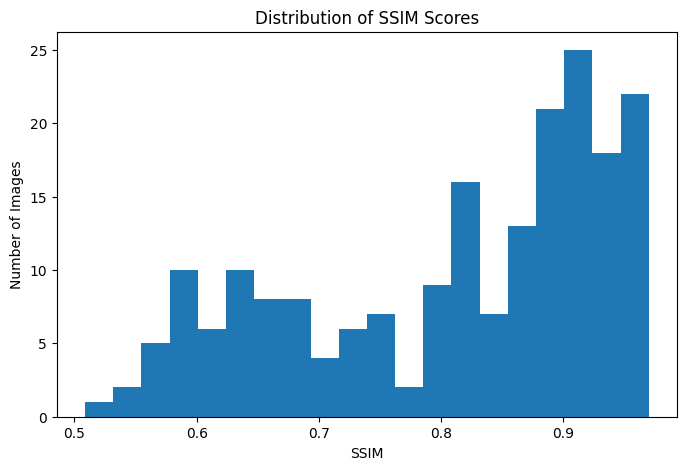

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(ssim_scores_v2, bins=20)

plt.title("Distribution of SSIM Scores")
plt.xlabel("SSIM")
plt.ylabel("Number of Images")

plt.show()

### Perbandingan Hasil Semua Model

Berikut adalah perbandingan nilai SSIM dari setiap percobaan yang sudah dilakukan.

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Improved",
        "Optimized",
        "Optimized V2"
    ],
    "Average SSIM": [
        0.7225,
        0.6769,
        0.5444,
        0.8091
    ],
    "Keterangan": [
        "Baseline",
        "Conv lebih dalam",
        "BatchNorm + Dropout",
        "Model Terbaik"
    ]
})

comparison

,Model,Average SSIM,Keterangan
0,Baseline,0.7225,Baseline
1,Improved,0.6769,Conv lebih dalam
2,Optimized,0.5444,BatchNorm + Dropout
3,Optimized V2,0.8091,Model Terbaik


### Ringkasan Hasil

Dari semua percobaan, **Optimized V2** memberikan hasil terbaik karena memiliki nilai SSIM paling tinggi. Oleh karena itu, model ini dipilih sebagai model akhir.

### Alasan Model Terbaik

Model **Optimized V2** dipilih sebagai model terbaik karena mendapatkan **rata-rata SSIM paling tinggi**, yaitu **0.8091**.

Hasil ini menunjukkan kalau gambar hasil rekonstruksi lebih mirip dengan gambar aslinya dibandingkan model-model sebelumnya.

Peningkatan ini didapat karena arsitektur yang digunakan lebih seimbang. Model tetap bisa mengambil fitur gambar dengan baik tanpa menambahkan layer yang justru membuat performanya turun.

### Hasil Hyperparameter Tuning

Selain mengubah arsitektur, dilakukan juga tuning hyperparameter, yaitu:

- Optimizer : Adam
- Learning Rate : 0.0005
- Batch Size : 16
- Maximum Epoch : 50
- Early Stopping (patience = 5)

Kombinasi hyperparameter ini membuat proses training lebih stabil dan membantu model mendapatkan hasil rekonstruksi yang lebih baik.

## Kesimpulan 

Pada project ini saya mencoba beberapa modifikasi arsitektur dan melakukan **hyperparameter tuning** untuk meningkatkan performa Autoencoder. Tidak semua percobaan memberikan hasil yang lebih baik. Beberapa model justru menghasilkan nilai SSIM yang lebih rendah dari model baseline.

Setelah dilakukan beberapa perbaikan, **Optimized V2** menjadi model terbaik dengan **Average SSIM sebesar 0.8091**, lebih tinggi dibandingkan **Baseline** yang mendapatkan **0.7225**. Hasil ini menunjukkan bahwa perubahan arsitektur yang tepat dan pemilihan hyperparameter yang sesuai berhasil membuat hasil rekonstruksi gambar menjadi lebih mirip dengan gambar aslinya.

Berdasarkan hasil tersebut, **Optimized V2 dipilih sebagai model terbaik** karena memberikan kualitas **dimension reduction** dan rekonstruksi gambar yang paling baik dibandingkan semua model yang telah diuji.

Video Penjelasan

Link Video : https://drive.google.com/file/d/1of-spmlTRrNei2VeWjNJOor6jKHc9VGb/view?usp=sharing